# Lab Task 02 — Effect of Image Filtering on Skin-Lesion Classification

**Objective:** Investigate how spatial-domain image-processing filters (Average, Gaussian,
Median, Sharpening, Sobel) affect the classification performance of the **three best
pretrained models identified in Lab Activity 1**:

| Rank | Model | Lab 1 Accuracy |
|---|---|---|
| 1 | **EfficientNetB0** | 63.75% |
| 2 | **ResNet50** | 61.25% |
| 3 | **ResNet18** | 58.75% |

Dataset: HAM10000 / ISIC Skin Cancer (same 5-class subset used in Lab 1), same split,
same preprocessing settings as Lab 1 — only the filtering condition changes, so the
comparison across filters is fair.

**Sections:** Dataset preparation → Filter definitions → Model loading → Baseline
experiment → Filtering experiments → Training → Evaluation → Visualization →
Comparative analysis → Discussion questions.


## Section 1 — Setup & Imports

In [1]:
!pip -q install kagglehub opencv-python-headless --upgrade

In [2]:
import os, time, random, copy
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torchvision import models, transforms
from torch.utils.data import Dataset, DataLoader
from PIL import Image

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    balanced_accuracy_score
)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("TensorFlow:", tf.__version__)
print("Torch device:", device)
gpus = tf.config.list_physical_devices('GPU')
print("Keras GPU available:", bool(gpus), gpus)

TensorFlow: 2.20.0
Torch device: cuda
Keras GPU available: True [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Section 2 — Dataset Preparation

Same dataset, same 5 classes, same 80/20 stratified train/val split, and same test set
as Lab Activity 1 — this is required so filtering is the *only* thing that changes
between experiments.

In [3]:
KAGGLE_NATIVE_PATH = "/kaggle/input/skin-cancer9-classesisic"

if os.path.exists(KAGGLE_NATIVE_PATH):
    print("Running inside a Kaggle notebook — using the attached dataset directly.")
    base_path = KAGGLE_NATIVE_PATH
else:
    print("Not on Kaggle — downloading dataset via kagglehub.")
    print("If you get an authentication error, upload your kaggle.json first:")
    print("  import os; os.makedirs('/root/.kaggle', exist_ok=True)")
    print("  !cp kaggle.json /root/.kaggle/ && chmod 600 /root/.kaggle/kaggle.json")
    import kagglehub
    base_path = kagglehub.dataset_download("nodoubttome/skin-cancer9-classesisic")

print("Dataset base path:", base_path)

Not on Kaggle — downloading dataset via kagglehub.
If you get an authentication error, upload your kaggle.json first:
  import os; os.makedirs('/root/.kaggle', exist_ok=True)
  !cp kaggle.json /root/.kaggle/ && chmod 600 /root/.kaggle/kaggle.json
Using Colab cache for faster access to the 'skin-cancer9-classesisic' dataset.
Dataset base path: /kaggle/input/skin-cancer9-classesisic


In [4]:

SELECTED_CLASSES = [
    "pigmented benign keratosis",
    "melanoma",
    "nevus",
    "basal cell carcinoma",
    "squamous cell carcinoma",
]
NUM_CLASSES = len(SELECTED_CLASSES)
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
IMAGE_EXTENSIONS = (".jpg", ".jpeg", ".png")

TRAIN_DIR = os.path.join(base_path, "Skin cancer ISIC The International Skin Imaging Collaboration", "Train")
TEST_DIR = os.path.join(base_path, "Skin cancer ISIC The International Skin Imaging Collaboration", "Test")

def get_image_paths_and_labels(folder, selected_classes):
    image_paths, labels = [], []
    for label, class_name in enumerate(selected_classes):
        class_folder = os.path.join(folder, class_name)
        for file_name in os.listdir(class_folder):
            if file_name.lower().endswith(IMAGE_EXTENSIONS):
                image_paths.append(os.path.join(class_folder, file_name))
                labels.append(label)
    return image_paths, labels

train_paths, train_labels = get_image_paths_and_labels(TRAIN_DIR, SELECTED_CLASSES)
test_paths, test_labels = get_image_paths_and_labels(TEST_DIR, SELECTED_CLASSES)

assert len(train_paths) > 0, "No training images found — check TRAIN_DIR/folder names above."
print("Total train+val images:", len(train_paths))
print("Total test images:", len(test_paths))

Total train+val images: 1814
Total test images: 80


In [5]:
train_paths_split, val_paths, train_labels_split, val_labels = train_test_split(
    train_paths, train_labels,
    test_size=0.20, random_state=SEED, stratify=train_labels
)

print("Training images:", len(train_paths_split))
print("Validation images:", len(val_paths))
print("Testing images:", len(test_paths))

def create_dataframe(image_paths, labels):
    return pd.DataFrame({
        "filename": image_paths,
        "class": [SELECTED_CLASSES[l] for l in labels]
    })

train_df = create_dataframe(train_paths_split, train_labels_split)
val_df = create_dataframe(val_paths, val_labels)
test_df = create_dataframe(test_paths, test_labels)

class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_labels_split),
    y=train_labels_split
)
class_weights = {i: float(w) for i, w in enumerate(class_weights_array)}
print("Class weights:", class_weights)

Training images: 1451
Validation images: 363
Testing images: 80
Class weights: {0: 0.786449864498645, 1: 0.8291428571428572, 2: 1.0146853146853148, 3: 0.9641196013289036, 4: 2.0013793103448276}


### Additional Analysis — HAM10000 Class Distribution

Required by the task: report how many images fall into each of the 5 selected classes.

class
pigmented benign keratosis    369
melanoma                      350
nevus                         286
basal cell carcinoma          301
squamous cell carcinoma       145
Name: count, dtype: int64


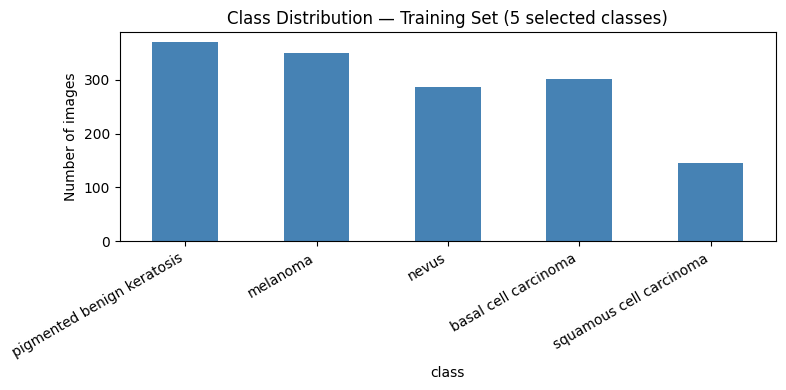

In [6]:
class_counts = train_df["class"].value_counts().reindex(SELECTED_CLASSES)
print(class_counts)

plt.figure(figsize=(8, 4))
class_counts.plot(kind="bar", color="steelblue")
plt.title("Class Distribution — Training Set (5 selected classes)")
plt.ylabel("Number of images")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig("class_distribution.png", dpi=150)
plt.show()

## Section 3 — Image Filtering

Five spatial-domain filters, each implemented as a function that takes a single RGB
image (as a NumPy array, values 0–255) and returns the filtered image in the same
format. These functions are used as the `preprocessing_function` inside Keras's
`ImageDataGenerator` (for EfficientNetB0 / ResNet50) and inside a custom `transform`
for the PyTorch ResNet18 pipeline, so exactly the same filter logic is applied to both
frameworks.

Each filter is applied **before** any model-specific normalization/rescaling, so the
filtering step is isolated from the backbone-specific preprocessing.

In [7]:
def apply_mean_filter(img, ksize=5):
    """Average/Mean filter — simple blur, replaces each pixel with the mean of its neighborhood."""
    return cv2.blur(img.astype(np.uint8), (ksize, ksize))

def apply_gaussian_filter(img, ksize=5, sigma=1.0):
    """Gaussian filter — weighted blur, weights follow a Gaussian centered on each pixel."""
    return cv2.GaussianBlur(img.astype(np.uint8), (ksize, ksize), sigma)

def apply_median_filter(img, ksize=5):
    """Median filter — replaces each pixel with the median of its neighborhood; good at
    removing salt-and-pepper noise while preserving edges better than mean/Gaussian."""
    return cv2.medianBlur(img.astype(np.uint8), ksize)

def apply_sharpening_filter(img):
    """Sharpening filter — unsharp-mask style kernel that boosts high-frequency detail
    (edges, texture) relative to the original image."""
    kernel = np.array([
        [0, -1, 0],
        [-1, 5, -1],
        [0, -1, 0]
    ], dtype=np.float32)
    sharpened = cv2.filter2D(img.astype(np.uint8), -1, kernel)
    return np.clip(sharpened, 0, 255).astype(np.uint8)

def apply_sobel_filter(img):
    """Sobel edge filter — computes horizontal + vertical gradients and combines them
    into a single edge-magnitude image, then replicates to 3 channels so the model still
    receives a 3-channel input the pretrained backbone expects."""
    gray = cv2.cvtColor(img.astype(np.uint8), cv2.COLOR_RGB2GRAY)
    sobel_x = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)
    sobel_y = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)
    magnitude = np.sqrt(sobel_x**2 + sobel_y**2)
    magnitude = np.clip((magnitude / (magnitude.max() + 1e-8)) * 255, 0, 255).astype(np.uint8)
    return cv2.cvtColor(magnitude, cv2.COLOR_GRAY2RGB)

FILTERS = {
    "Baseline (no filter)": None,
    "Mean": apply_mean_filter,
    "Gaussian": apply_gaussian_filter,
    "Median": apply_median_filter,
    "Sharpening": apply_sharpening_filter,
    "Sobel": apply_sobel_filter,
}

def make_filter_fn(filter_func):
    """Wraps a filter into a function Keras' ImageDataGenerator can call per-image
    (input/output both float32 arrays, as Keras expects)."""
    if filter_func is None:
        return None
    def _fn(img):
        filtered = filter_func(img)
        return filtered.astype(np.float32)
    return _fn

def safe_filter_name(name):
    """Keras model names can't contain spaces or parentheses — this makes a
    filesystem/Keras-safe version of a filter name for use in model names and filenames."""
    return name.replace(" ", "_").replace("(", "").replace(")", "")

### Additional Analysis — Original vs Filtered Image Examples

Required by the task: visualize one example image under each filtering condition.

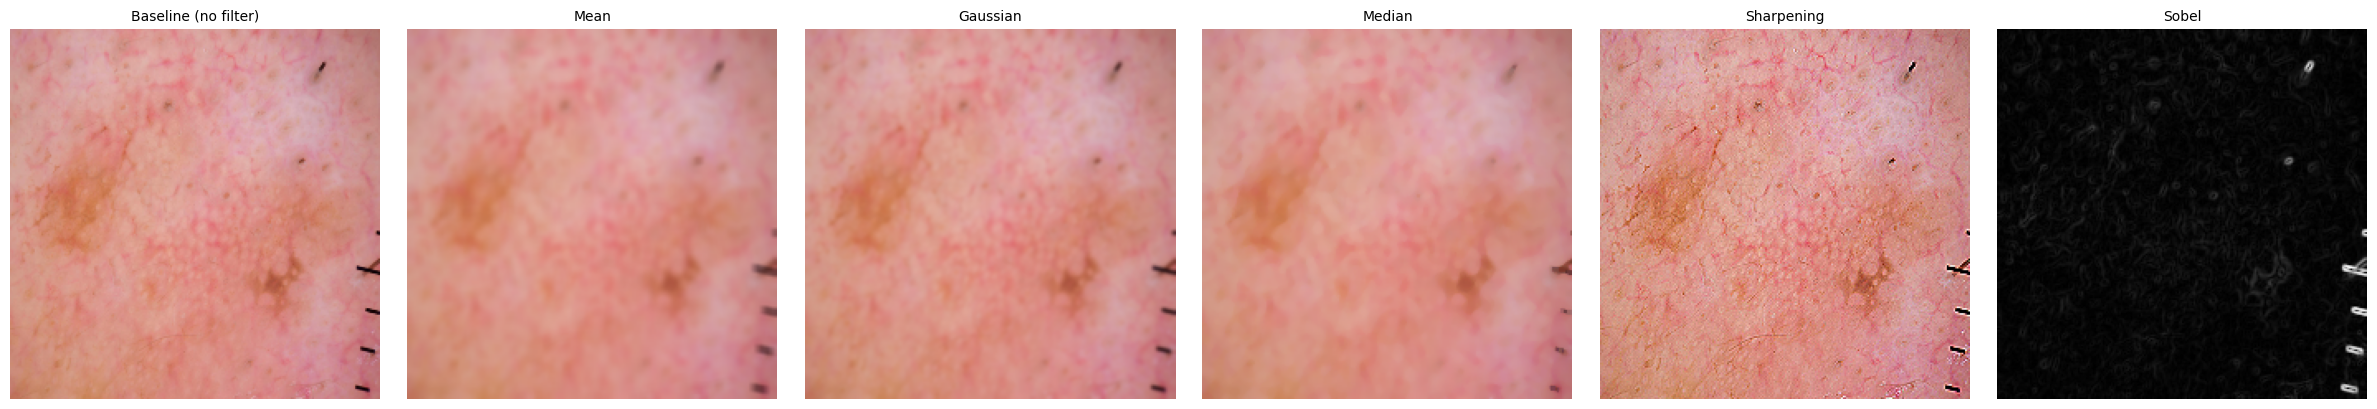

In [8]:
sample_path = train_df["filename"].iloc[0]
sample_img = cv2.cvtColor(cv2.imread(sample_path), cv2.COLOR_BGR2RGB)
sample_img = cv2.resize(sample_img, IMG_SIZE)

fig, axes = plt.subplots(1, len(FILTERS), figsize=(4 * len(FILTERS), 4))
for ax, (name, func) in zip(axes, FILTERS.items()):
    out = sample_img if func is None else func(sample_img)
    ax.imshow(out.astype(np.uint8) if out.ndim == 3 else out, cmap=None if out.ndim == 3 else "gray")
    ax.set_title(name, fontsize=10)
    ax.axis("off")
plt.tight_layout()
plt.savefig("filter_examples.png", dpi=150)
plt.show()

## Section 4 — Model Loading

The three best models from Lab Activity 1: **EfficientNetB0** and **ResNet50**
(Keras, `include_top=False` + a small custom classification head, matching Lab 1's
architecture), and **ResNet18** (PyTorch/torchvision, matching Lab 1's implementation).

In [9]:
from tensorflow.keras.applications import EfficientNetB0, ResNet50

def build_transfer_model(base_model, name):
    """Same head architecture used in Lab 1: GAP -> Dropout -> Dense(256) -> Dropout -> Dense(softmax)."""
    base_model.trainable = False
    inputs = keras.Input(shape=(224, 224, 3))
    x = base_model(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(256, activation="relu")(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(NUM_CLASSES, activation="softmax")(x)
    model = keras.Model(inputs, outputs, name=name)
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-4),
        loss="categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model

In [10]:
class ResNet18Wrapper(nn.Module):
    """Thin wrapper so ResNet18 exposes the same .fit()-style training loop used for
    the Keras models isn't needed -- ResNet18 uses the PyTorch loop below instead."""
    def __init__(self, num_classes):
        super().__init__()
        weights = models.ResNet18_Weights.DEFAULT
        self.backbone = models.resnet18(weights=weights)
        self.backbone.fc = nn.Linear(self.backbone.fc.in_features, num_classes)

    def forward(self, x):
        return self.backbone(x)

## Section 5 — Data Pipelines (per model, per filter)

`make_keras_generators` builds train/val/test generators for a Keras model, with a
given filter function applied as `preprocessing_function` (applied to every image
before the model's own normalization). `make_pytorch_loaders` does the equivalent for
ResNet18 using a custom `Dataset` that applies the filter with OpenCV before converting
to a tensor.

**Keep everything else identical to Lab 1** (batch size, image size, class weights,
number of epochs) — only the filter changes between experiments, which is required for
a fair comparison.

In [11]:
def make_keras_generators(filter_func, model_type="rescale"):
    """
    model_type: 'rescale' -> plain 1/255 scaling after filtering (used here for simplicity
                across both EfficientNetB0 and ResNet50 so the filter's effect is isolated
                and not confounded with different backbone-specific normalizations).
    """
    filt = make_filter_fn(filter_func)

    def combined_preprocess(img):
        if filt is not None:
            img = filt(img)
        return img / 255.0

    train_datagen = ImageDataGenerator(
        preprocessing_function=combined_preprocess,
        rotation_range=20, width_shift_range=0.15, height_shift_range=0.15,
        zoom_range=0.15, horizontal_flip=True, fill_mode="reflect",
    )
    val_test_datagen = ImageDataGenerator(preprocessing_function=combined_preprocess)

    train_gen = train_datagen.flow_from_dataframe(
        train_df, x_col="filename", y_col="class",
        target_size=IMG_SIZE, batch_size=BATCH_SIZE,
        class_mode="categorical", classes=SELECTED_CLASSES,
        shuffle=True, seed=SEED,
    )
    val_gen = val_test_datagen.flow_from_dataframe(
        val_df, x_col="filename", y_col="class",
        target_size=IMG_SIZE, batch_size=BATCH_SIZE,
        class_mode="categorical", classes=SELECTED_CLASSES,
        shuffle=False,
    )
    test_gen = val_test_datagen.flow_from_dataframe(
        test_df, x_col="filename", y_col="class",
        target_size=IMG_SIZE, batch_size=BATCH_SIZE,
        class_mode="categorical", classes=SELECTED_CLASSES,
        shuffle=False,
    )
    return train_gen, val_gen, test_gen

In [12]:
class FilteredSkinDataset(Dataset):
    def __init__(self, df, filter_func, augment=False):
        self.paths = df["filename"].tolist()
        self.labels = [SELECTED_CLASSES.index(c) for c in df["class"].tolist()]
        self.filter_func = filter_func
        self.augment = augment
        self.normalize = transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                               std=[0.229, 0.224, 0.225])

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img = cv2.cvtColor(cv2.imread(self.paths[idx]), cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, IMG_SIZE)
        if self.filter_func is not None:
            img = self.filter_func(img)
        img = img.astype(np.float32) / 255.0
        tensor = torch.from_numpy(img.transpose(2, 0, 1))
        tensor = self.normalize(tensor)
        return tensor, self.labels[idx]

def make_pytorch_loaders(filter_func):
    train_ds = FilteredSkinDataset(train_df, filter_func, augment=True)
    val_ds = FilteredSkinDataset(val_df, filter_func)
    test_ds = FilteredSkinDataset(test_df, filter_func)
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
    test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)
    return train_loader, val_loader, test_loader

## Section 6 — Training

Two training functions — one for the Keras models (EfficientNetB0, ResNet50), one for
the PyTorch model (ResNet18) — both using the same settings across every filter
condition: same epochs, same optimizer/learning rate, same class weights.

In [13]:
def train_keras_model(model, train_gen, val_gen, epochs=5):
    callbacks = [
        keras.callbacks.EarlyStopping(monitor="val_loss", patience=2, restore_best_weights=True),
        keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=1, min_lr=1e-6),
    ]
    history = model.fit(
        train_gen, validation_data=val_gen, epochs=epochs,
        class_weight=class_weights, callbacks=callbacks, verbose=1,
    )
    return history

In [14]:
def train_pytorch_model(model, train_loader, val_loader, epochs=5, lr=1e-4):
    model = model.to(device)
    class_weights_tensor = torch.tensor(
        [class_weights[i] for i in range(NUM_CLASSES)], dtype=torch.float32
    ).to(device)
    criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    history = {"loss": [], "val_loss": [], "accuracy": [], "val_accuracy": []}

    for epoch in range(epochs):
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            out = model(x)
            loss = criterion(out, y)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * x.size(0)
            correct += (out.argmax(1) == y).sum().item()
            total += x.size(0)
        train_loss, train_acc = running_loss / total, correct / total

        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0
        with torch.no_grad():
            for x, y in val_loader:
                x, y = x.to(device), y.to(device)
                out = model(x)
                loss = criterion(out, y)
                val_loss += loss.item() * x.size(0)
                val_correct += (out.argmax(1) == y).sum().item()
                val_total += x.size(0)
        val_loss, val_acc = val_loss / val_total, val_correct / val_total

        history["loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["accuracy"].append(train_acc)
        history["val_accuracy"].append(val_acc)
        print(f"Epoch {epoch+1}/{epochs} — loss: {train_loss:.4f} acc: {train_acc:.4f} "
              f"val_loss: {val_loss:.4f} val_acc: {val_acc:.4f}")

    return history

## Section 7 — Evaluation

Computes accuracy, macro precision/recall/F1, macro-AUC, and **balanced accuracy**
(required by the task, since the class distribution is imbalanced) for both frameworks,
plus the confusion matrix used in the Additional Analysis section.

In [15]:
def evaluate_keras_model(model, test_gen, model_name):
    test_gen.reset()
    y_prob = model.predict(test_gen, verbose=0)
    y_pred = np.argmax(y_prob, axis=1)
    y_true = test_gen.classes
    return _compute_metrics(y_true, y_pred, y_prob, model_name)

def evaluate_pytorch_model(model, test_loader, model_name):
    model.eval()
    all_probs, all_true = [], []
    with torch.no_grad():
        for x, y in test_loader:
            x = x.to(device)
            out = torch.softmax(model(x), dim=1).cpu().numpy()
            all_probs.append(out)
            all_true.append(y.numpy())
    y_prob = np.concatenate(all_probs)
    y_true = np.concatenate(all_true)
    y_pred = np.argmax(y_prob, axis=1)
    return _compute_metrics(y_true, y_pred, y_prob, model_name)

def _compute_metrics(y_true, y_pred, y_prob, model_name):
    result = {
        "Model": model_name,
        "Accuracy (%)": accuracy_score(y_true, y_pred) * 100,
        "Balanced Accuracy (%)": balanced_accuracy_score(y_true, y_pred) * 100,
        "Precision (macro, %)": precision_score(y_true, y_pred, average="macro", zero_division=0) * 100,
        "Recall (macro, %)": recall_score(y_true, y_pred, average="macro", zero_division=0) * 100,
        "Macro-F1 (%)": f1_score(y_true, y_pred, average="macro", zero_division=0) * 100,
        "AUC (macro, %)": roc_auc_score(y_true, y_prob, multi_class="ovr", average="macro") * 100,
    }
    report = classification_report(y_true, y_pred, target_names=SELECTED_CLASSES,
                                     output_dict=True, zero_division=0)
    cm = confusion_matrix(y_true, y_pred)
    return result, report, cm

## Section 8 — Baseline Experiment & Filtering Experiments (main loop)

This is the core of Task 2: for each of the 3 best models, run the **baseline**
(no filter) plus each of the **5 filters**, using identical settings otherwise.
Results, classification reports, confusion matrices, and training curves are stored
per (model, filter) pair so the comparison table and all required visualizations can
be built from them afterward.

⚠️ **Runtime note:** 3 models × 6 conditions = 18 training runs. On a Colab T4 GPU with
`EPOCHS=5`, this is the main time cost of the whole notebook — expect roughly
1.5–3 hours total depending on dataset size. Reduce `EPOCHS` for a quick smoke-test
run first, then increase for your final submission run.

In [16]:
EPOCHS = 5

all_experiment_results = {}
all_experiment_reports = {}
all_experiment_cms = {}
all_experiment_histories = {}

In [17]:

for filter_name, filter_func in FILTERS.items():
    print(f"\n{'='*60}\nEfficientNetB0 — {filter_name}\n{'='*60}")
    train_gen, val_gen, test_gen = make_keras_generators(filter_func)
    base = EfficientNetB0(weights="imagenet", include_top=False, input_shape=(224, 224, 3))
    model = build_transfer_model(base, f"EfficientNetB0_{safe_filter_name(filter_name)}")
    history = train_keras_model(model, train_gen, val_gen, epochs=EPOCHS)
    metrics, report, cm = evaluate_keras_model(model, test_gen, "EfficientNetB0")

    key = ("EfficientNetB0", filter_name)
    all_experiment_results[key] = metrics
    all_experiment_reports[key] = report
    all_experiment_cms[key] = cm
    all_experiment_histories[key] = history.history
    print(metrics)


EfficientNetB0 — Baseline (no filter)
Found 1451 validated image filenames belonging to 5 classes.
Found 363 validated image filenames belonging to 5 classes.
Found 80 validated image filenames belonging to 5 classes.
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/5
46/46 ━━━━━━━━━━━━━━━━━━━━ 131s 2s/step - accuracy: 0.1854 - loss: 1.6388 - val_accuracy: 0.2562 - val_loss: 1.5941 - learning_rate: 1.0000e-04
Epoch 2/5
46/46 ━━━━━━━━━━━━━━━━━━━━ 47s 1s/step - accuracy: 0.2274 - loss: 1.6356 - val_accuracy: 0.0992 - val_loss: 1.6460 - learning_rate: 1.0000e-04
Epoch 3/5
46/46 ━━━━━━━━━━━━━━━━━━━━ 50s 1s/step - accuracy: 0.2040 - loss: 1.6312 - val_accuracy: 0.0992 - val_loss: 1.6147 - learning_rate: 5.0000e-05
{'Model': 'EfficientNetB0', 'Accuracy (%)': 20.0, 'Balanced Accuracy (%)': np.float64(20.0), 'Precision (macro, %)': 4.0, 'Recall (macro, %)': 20.0, 'Macro-F1 (%)': 6.666666666666667, 'AUC (macro, %)': np.float64(47.98828125)}

EfficientNetB0 — Mean
Found 1451 validated

{'Model': 'EfficientNetB0', 'Accuracy (%)': 20.0, 'Balanced Accuracy (%)': np.float64(20.0), 'Precision (macro, %)': 4.0, 'Recall (macro, %)': 20.0, 'Macro-F1 (%)': 6.666666666666667, 'AUC (macro, %)': np.float64(63.74999999999999)}

EfficientNetB0 — Median
Found 1451 validated image filenames belonging to 5 classes.
Found 363 validated image filenames belonging to 5 classes.
Found 80 validated image filenames belonging to 5 classes.
Epoch 1/5
46/46 ━━━━━━━━━━━━━━━━━━━━ 82s 1s/step - accuracy: 0.1999 - loss: 1.6337 - val_accuracy: 0.2562 - val_loss: 1.5932 - learning_rate: 1.0000e-04
Epoch 2/5
46/46 ━━━━━━━━━━━━━━━━━━━━ 38s 829ms/step - accuracy: 0.1985 - loss: 1.6436 - val_accuracy: 0.0992 - val_loss: 1.6487 - learning_rate: 1.0000e-04
Epoch 3/5
46/46 ━━━━━━━━━━━━━━━━━━━━ 38s 819ms/step - accuracy: 0.1764 - loss: 1.6281 - val_accuracy: 0.0992 - val_loss: 1.6119 - learning_rate: 5.0000e-05
{'Model': 'EfficientNetB0', 'Accuracy (%)': 20.0, 'Balanced Accuracy (%)': np.float64(20.0), 'Pre

In [18]:

from tensorflow.keras.applications import ResNet50

for filter_name, filter_func in FILTERS.items():
    print(f"\n{'='*60}\nResNet50 — {filter_name}\n{'='*60}")
    train_gen, val_gen, test_gen = make_keras_generators(filter_func)
    base = ResNet50(weights="imagenet", include_top=False, input_shape=(224, 224, 3))
    model = build_transfer_model(base, f"ResNet50_{safe_filter_name(filter_name)}")
    history = train_keras_model(model, train_gen, val_gen, epochs=EPOCHS)
    metrics, report, cm = evaluate_keras_model(model, test_gen, "ResNet50")

    key = ("ResNet50", filter_name)
    all_experiment_results[key] = metrics
    all_experiment_reports[key] = report
    all_experiment_cms[key] = cm
    all_experiment_histories[key] = history.history
    print(metrics)


ResNet50 — Baseline (no filter)
Found 1451 validated image filenames belonging to 5 classes.
Found 363 validated image filenames belonging to 5 classes.
Found 80 validated image filenames belonging to 5 classes.
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/5
46/46 ━━━━━━━━━━━━━━━━━━━━ 63s 1s/step - accuracy: 0.2074 - loss: 1.8038 - val_accuracy: 0.0964 - val_loss: 1.6507 - learning_rate: 1.0000e-04
Epoch 2/5
46/46 ━━━━━━━━━━━━━━━━━━━━ 38s 819ms/step - accuracy: 0.2040 - loss: 1.7380 - val_accuracy: 0.2259 - val_loss: 1.6219 - learning_rate: 1.0000e-04
Epoch 3/5
46/46 ━━━━━━━━━━━━━━━━━━━━ 38s 835ms/step - accuracy: 0.2033 - loss: 1.7165 - val_accuracy: 0.2590 - val_loss: 1.5997 - learning_rate: 1.0000e-04
Epoch 4/5
46/46 ━━━━━━━━━━━━━━━━━━━━ 39s 845ms/step - accuracy: 0.1964 - loss: 1.7005 - val_accuracy: 0.0992 - val_loss: 1.6444 - learning_rate: 1.0000e-04
Epoch 5/5
46/46 ━━━━━━━━━━━━━━━━━━━━ 38s 817ms/step - accuracy: 0.1916 - loss: 1.6895 - val_accuracy: 0.0992 - val_

In [19]:

for filter_name, filter_func in FILTERS.items():
    print(f"\n{'='*60}\nResNet18 — {filter_name}\n{'='*60}")
    train_loader, val_loader, test_loader = make_pytorch_loaders(filter_func)
    model = ResNet18Wrapper(NUM_CLASSES)
    history = train_pytorch_model(model, train_loader, val_loader, epochs=EPOCHS)
    metrics, report, cm = evaluate_pytorch_model(model, test_loader, "ResNet18")

    key = ("ResNet18", filter_name)
    all_experiment_results[key] = metrics
    all_experiment_reports[key] = report
    all_experiment_cms[key] = cm
    all_experiment_histories[key] = history
    print(metrics)


ResNet18 — Baseline (no filter)
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 162MB/s]


Epoch 1/5 — loss: 1.0052 acc: 0.6051 val_loss: 0.7332 val_acc: 0.7603
Epoch 2/5 — loss: 0.3391 acc: 0.8904 val_loss: 0.7227 val_acc: 0.7631
Epoch 3/5 — loss: 0.1050 acc: 0.9862 val_loss: 0.6207 val_acc: 0.7906
Epoch 4/5 — loss: 0.0422 acc: 0.9972 val_loss: 0.6199 val_acc: 0.7879
Epoch 5/5 — loss: 0.0186 acc: 1.0000 val_loss: 0.6701 val_acc: 0.7934
{'Model': 'ResNet18', 'Accuracy (%)': 61.25000000000001, 'Balanced Accuracy (%)': np.float64(61.25000000000001), 'Precision (macro, %)': 65.2958152958153, 'Recall (macro, %)': 61.25000000000001, 'Macro-F1 (%)': 59.46575731741972, 'AUC (macro, %)': np.float64(84.62890625)}

ResNet18 — Mean
Epoch 1/5 — loss: 1.0722 acc: 0.5810 val_loss: 0.7701 val_acc: 0.7383
Epoch 2/5 — loss: 0.3815 acc: 0.8794 val_loss: 0.7996 val_acc: 0.7245
Epoch 3/5 — loss: 0.1621 acc: 0.9649 val_loss: 0.7695 val_acc: 0.7493
Epoch 4/5 — loss: 0.0622 acc: 0.9924 val_loss: 0.6975 val_acc: 0.7769
Epoch 5/5 — loss: 0.0306 acc: 0.9972 val_loss: 0.7013 val_acc: 0.7686
{'Model': 

## Section 9 — Visualization

Confusion matrices, training/validation accuracy curves, and training/validation loss
curves for every (model, filter) combination — required by the Additional Analysis
section of the task.

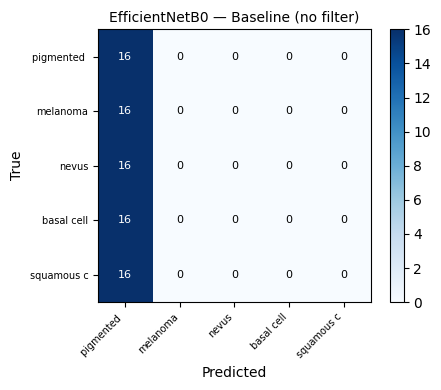

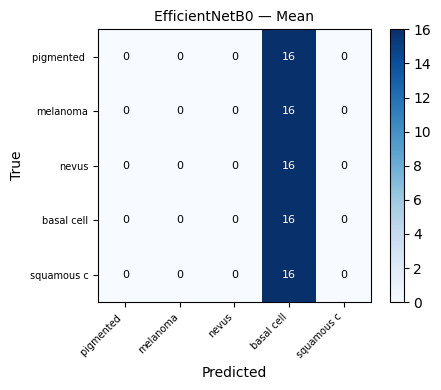

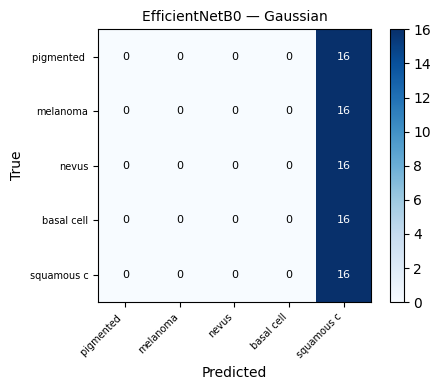

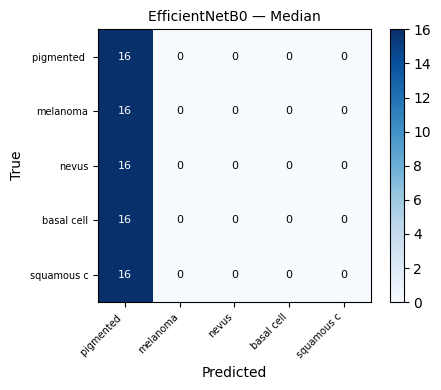

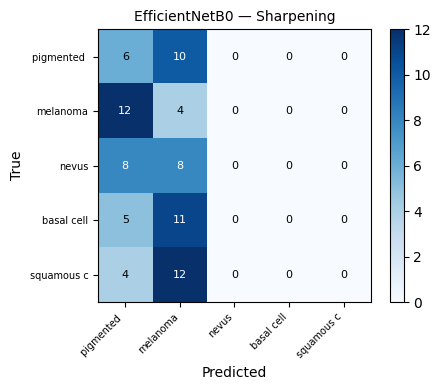

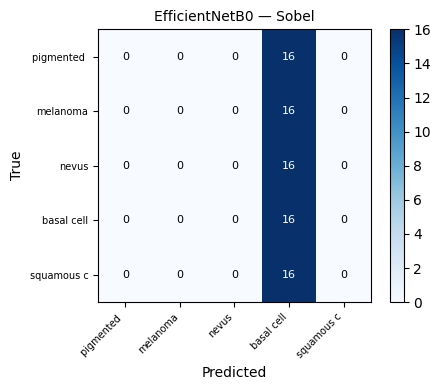

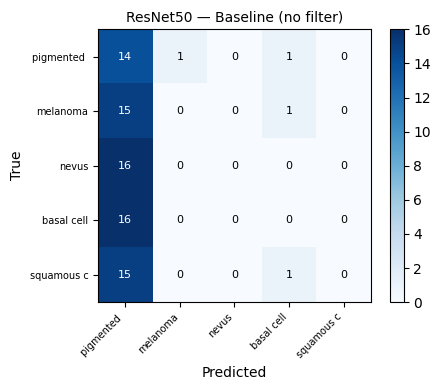

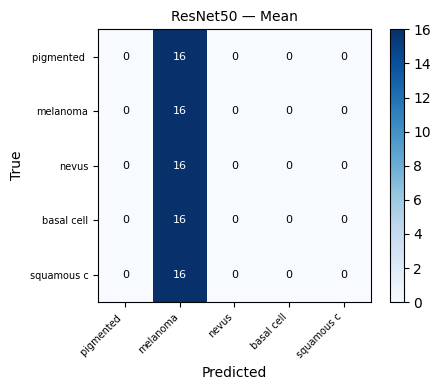

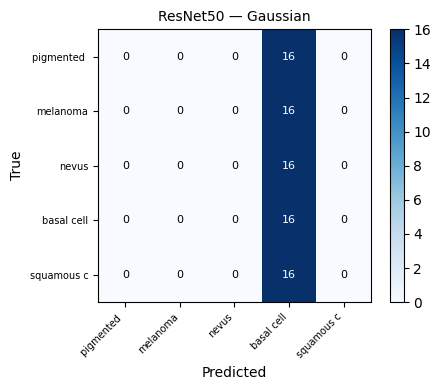

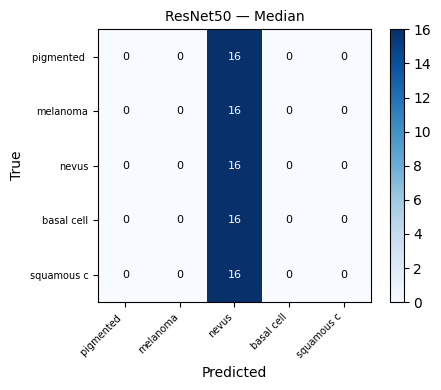

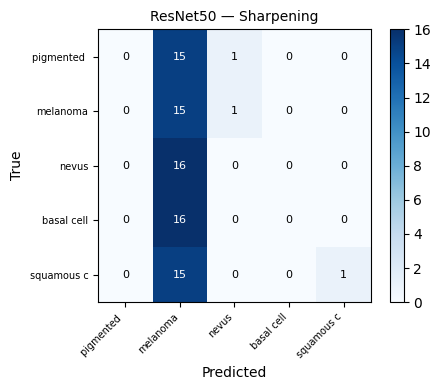

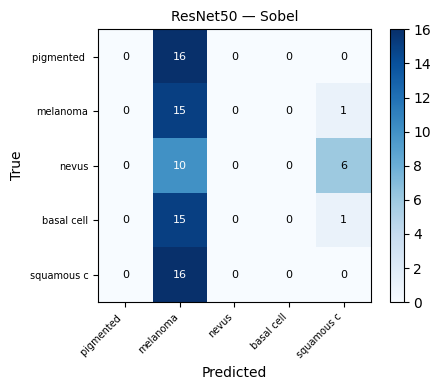

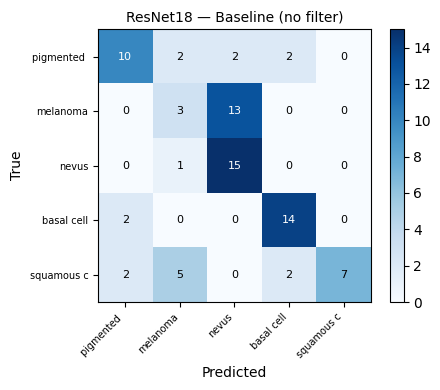

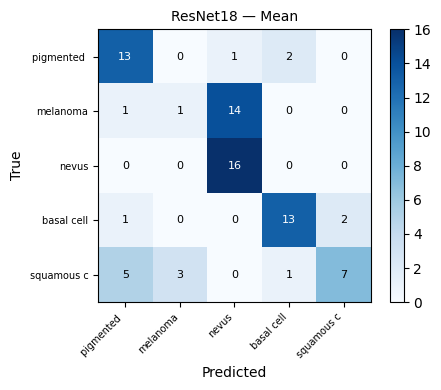

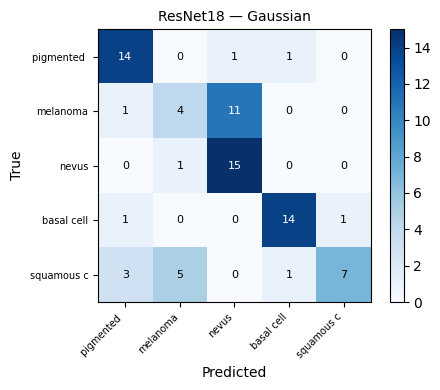

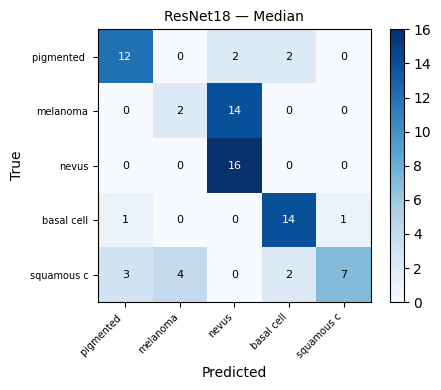

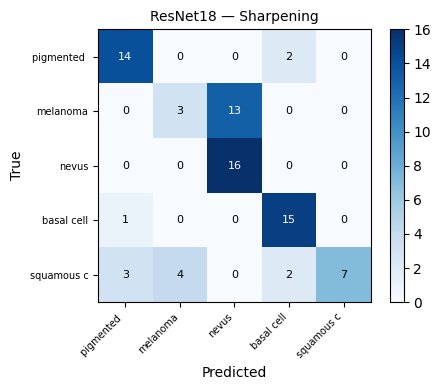

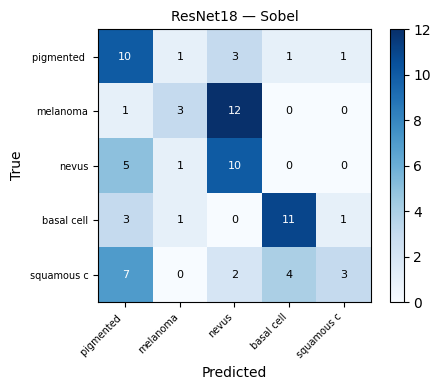

In [20]:
def plot_confusion_matrix(cm, title):
    plt.figure(figsize=(5, 4))
    plt.imshow(cm, cmap="Blues")
    plt.title(title, fontsize=10)
    plt.colorbar()
    plt.xticks(range(NUM_CLASSES), [c[:10] for c in SELECTED_CLASSES], rotation=45, ha="right", fontsize=7)
    plt.yticks(range(NUM_CLASSES), [c[:10] for c in SELECTED_CLASSES], fontsize=7)
    for i in range(NUM_CLASSES):
        for j in range(NUM_CLASSES):
            plt.text(j, i, cm[i, j], ha="center", va="center",
                      color="white" if cm[i, j] > cm.max()/2 else "black", fontsize=8)
    plt.ylabel("True")
    plt.xlabel("Predicted")
    plt.tight_layout()

for (model_name, filter_name), cm in all_experiment_cms.items():
    plot_confusion_matrix(cm, f"{model_name} — {filter_name}")
    plt.savefig(f"cm_{model_name}_{safe_filter_name(filter_name)}.png", dpi=120)
    plt.show()

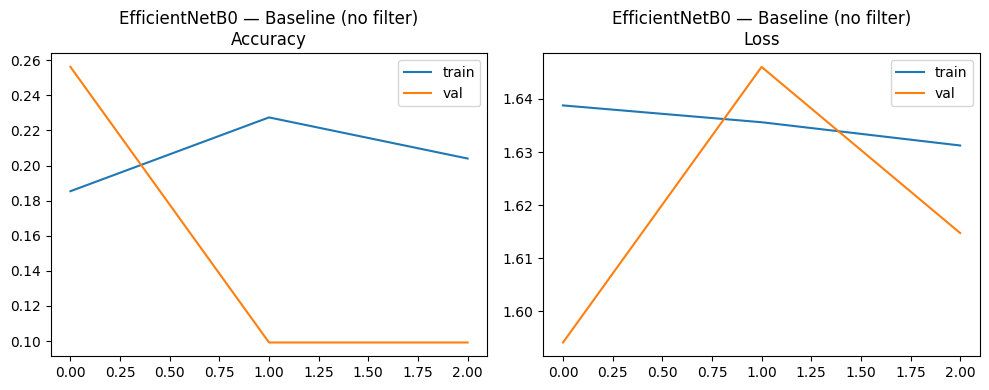

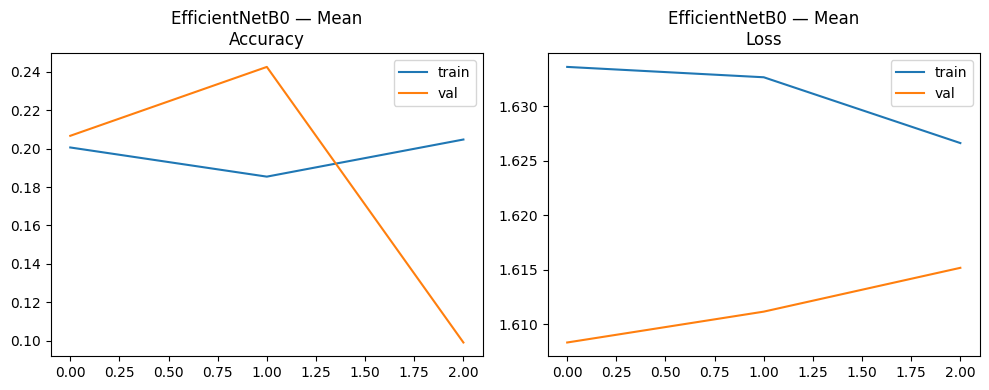

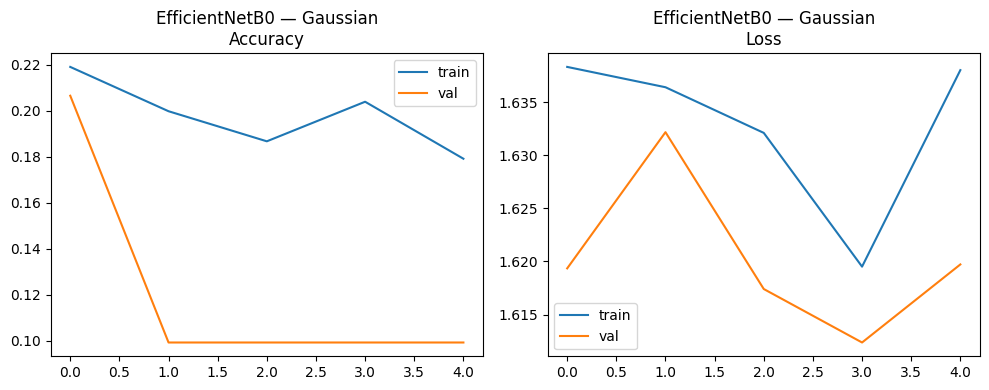

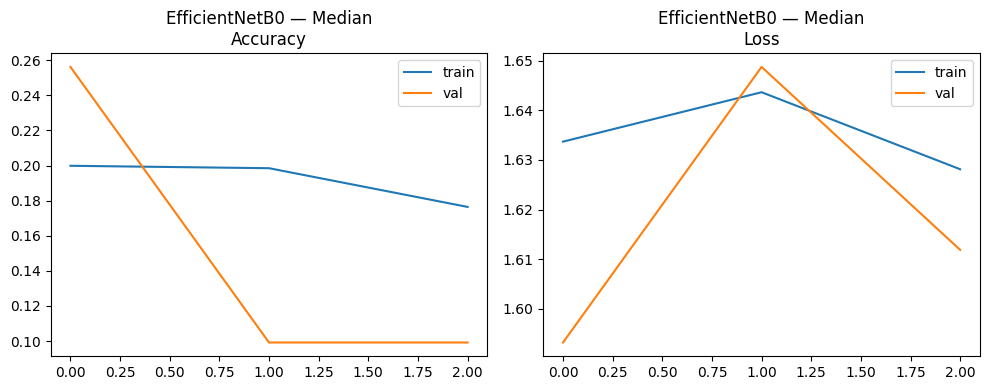

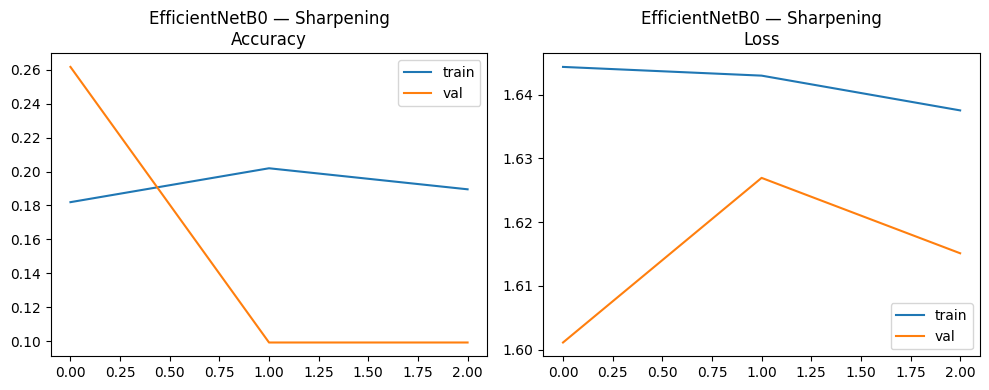

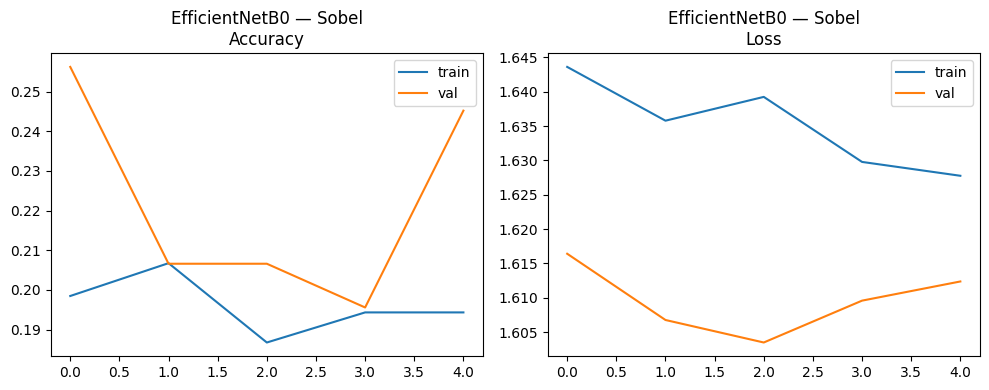

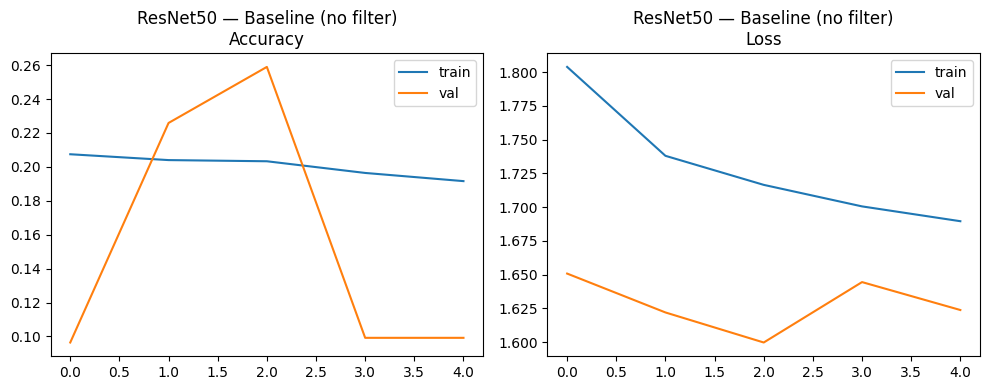

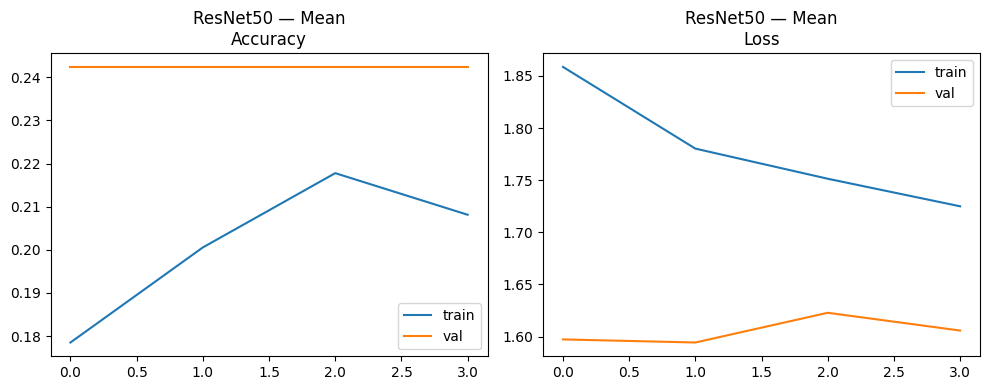

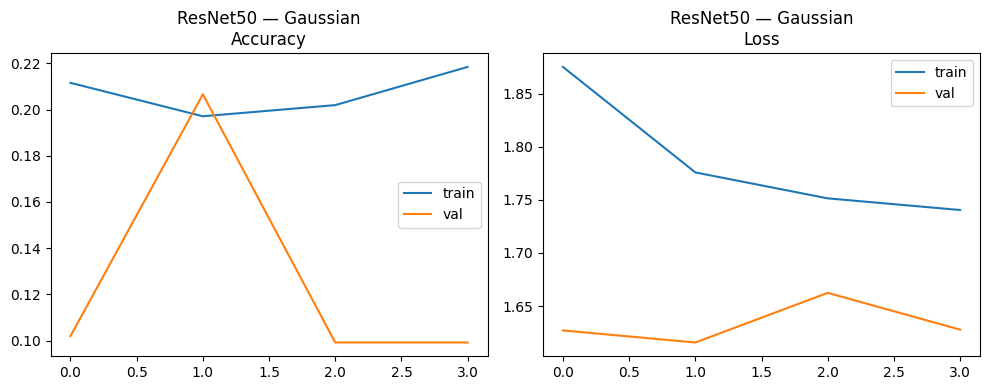

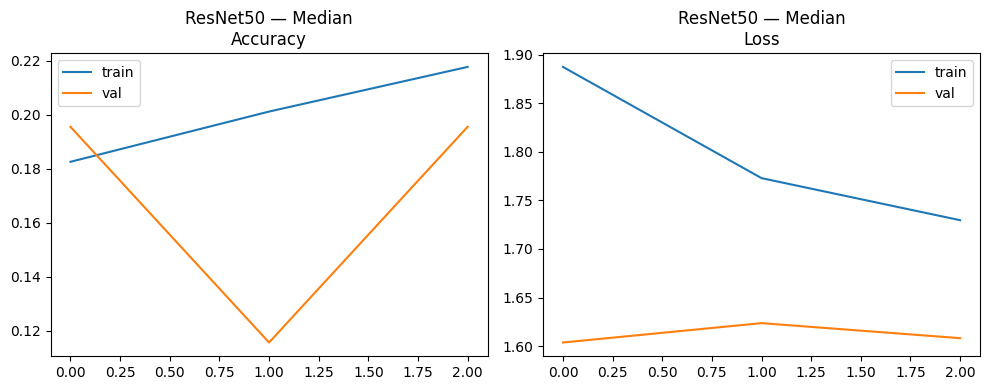

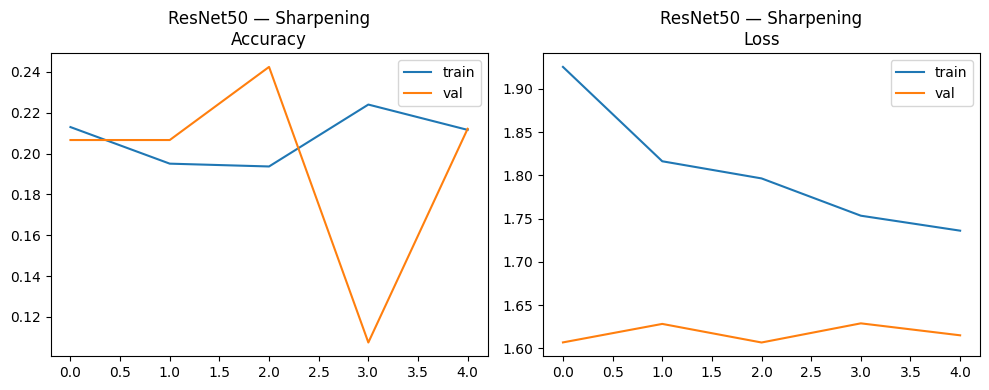

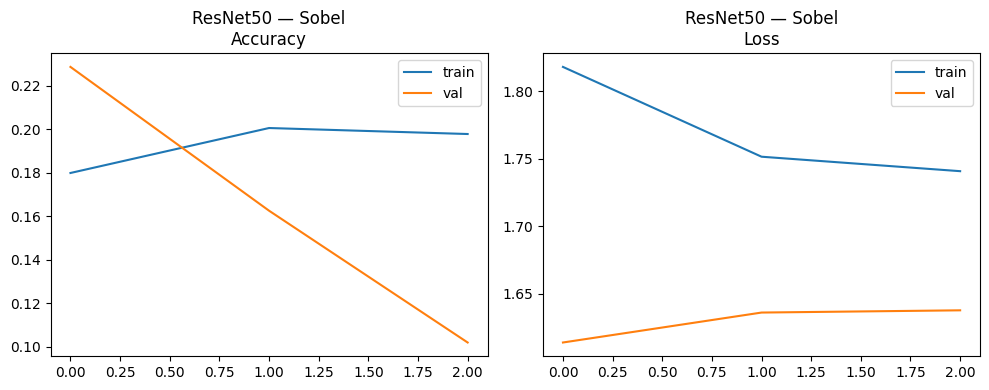

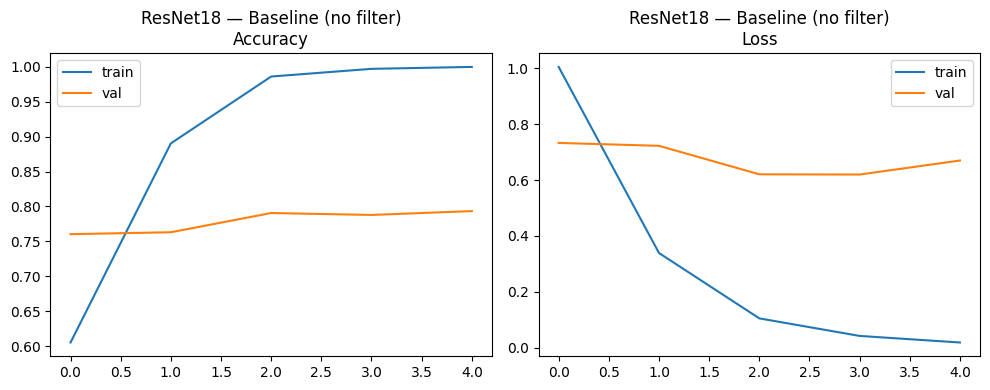

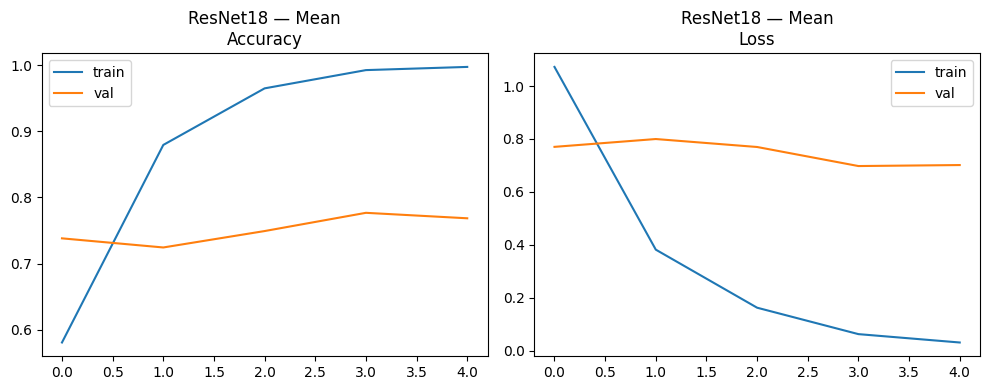

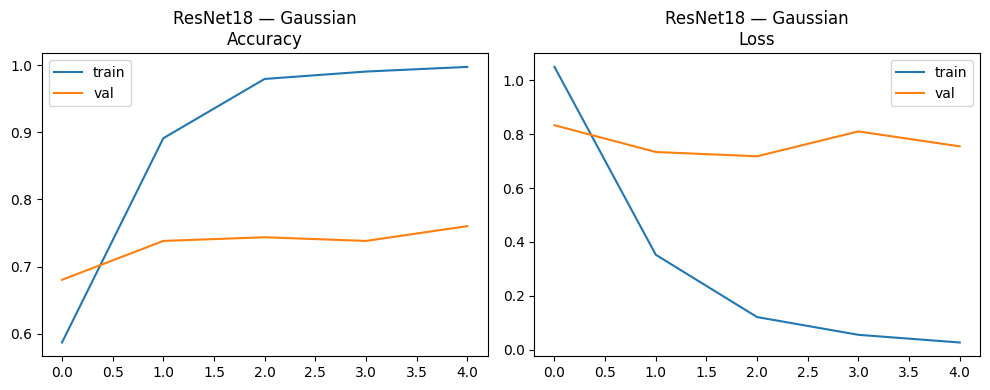

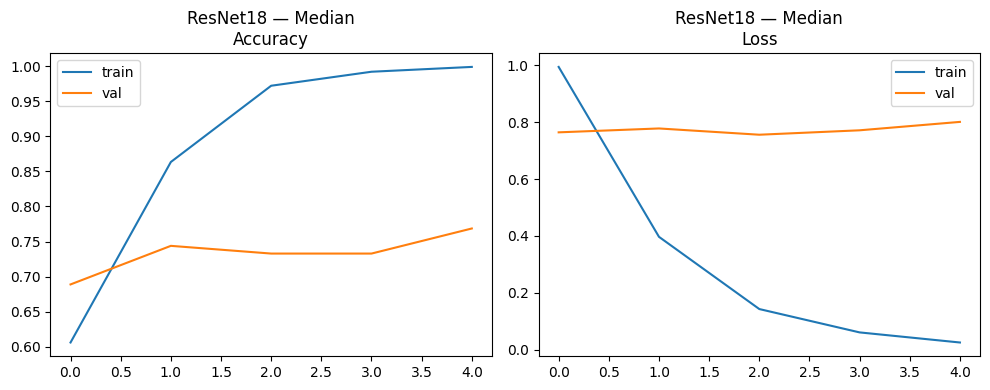

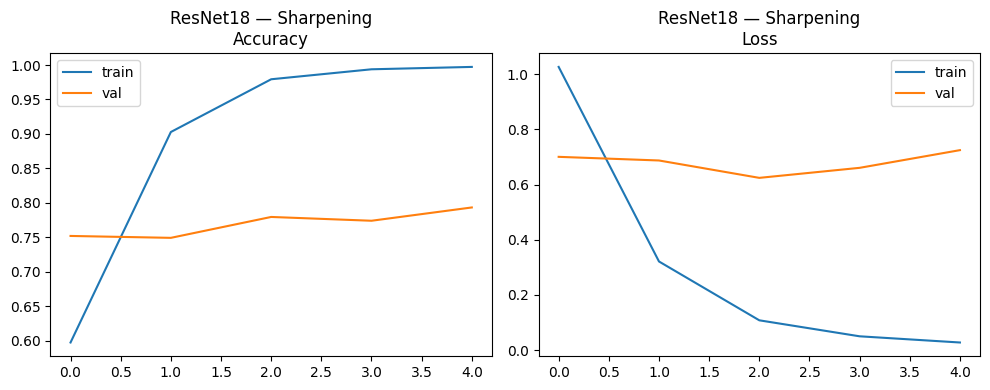

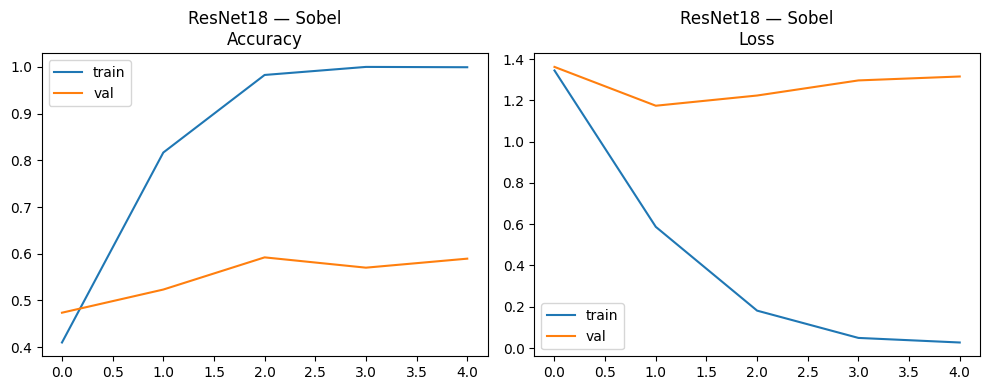

In [21]:
def get_curve(history, key_train, key_val):
    """Keras History objects and our plain PyTorch dict both expose the same keys
    (accuracy/val_accuracy, loss/val_loss), so this works for either."""
    return history.get(key_train, []), history.get(key_val, [])

for (model_name, filter_name), history in all_experiment_histories.items():
    acc, val_acc = get_curve(history, "accuracy", "val_accuracy")
    loss, val_loss = get_curve(history, "loss", "val_loss")

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    axes[0].plot(acc, label="train"); axes[0].plot(val_acc, label="val")
    axes[0].set_title(f"{model_name} — {filter_name}\nAccuracy"); axes[0].legend()
    axes[1].plot(loss, label="train"); axes[1].plot(val_loss, label="val")
    axes[1].set_title(f"{model_name} — {filter_name}\nLoss"); axes[1].legend()
    plt.tight_layout()
    fname = f"curves_{model_name}_{safe_filter_name(filter_name)}.png"
    plt.savefig(fname, dpi=120)
    plt.show()

### Additional Analysis — Per-Class Precision, Recall, F1-Score

Printed per (model, filter) combination from the stored `classification_report` dicts.

In [22]:
for (model_name, filter_name), report in all_experiment_reports.items():
    print(f"\n=== {model_name} — {filter_name} ===")
    per_class_df = pd.DataFrame(report).T.loc[SELECTED_CLASSES, ["precision", "recall", "f1-score"]]
    print((per_class_df * 100).round(2))


=== EfficientNetB0 — Baseline (no filter) ===
                            precision  recall  f1-score
pigmented benign keratosis       20.0   100.0     33.33
melanoma                          0.0     0.0      0.00
nevus                             0.0     0.0      0.00
basal cell carcinoma              0.0     0.0      0.00
squamous cell carcinoma           0.0     0.0      0.00

=== EfficientNetB0 — Mean ===
                            precision  recall  f1-score
pigmented benign keratosis        0.0     0.0      0.00
melanoma                          0.0     0.0      0.00
nevus                             0.0     0.0      0.00
basal cell carcinoma             20.0   100.0     33.33
squamous cell carcinoma           0.0     0.0      0.00

=== EfficientNetB0 — Gaussian ===
                            precision  recall  f1-score
pigmented benign keratosis        0.0     0.0      0.00
melanoma                          0.0     0.0      0.00
nevus                             0.0     0.0  

## Section 10 — Comparative Analysis Table

The required comparison table: each of the 3 models × 6 conditions (baseline + 5
filters), with Accuracy, Balanced Accuracy, Macro-F1, and Macro-AUC.

In [23]:
comparison_rows = []
for (model_name, filter_name), metrics in all_experiment_results.items():
    row = {"Model": model_name, "Condition": filter_name}
    row.update({k: v for k, v in metrics.items() if k != "Model"})
    comparison_rows.append(row)

comparison_df = pd.DataFrame(comparison_rows)
comparison_df = comparison_df.sort_values(["Model", "Condition"])
comparison_df = comparison_df.round(2)

display(comparison_df)
comparison_df.to_csv("task2_comparison_table.csv", index=False)
print("Saved: task2_comparison_table.csv")

,Model,Condition,Accuracy (%),Balanced Accuracy (%),"Precision (macro, %)","Recall (macro, %)",Macro-F1 (%),"AUC (macro, %)"
0,EfficientNetB0,Baseline (no filter),20.00,20.00,4.00,20.00,6.67,47.99
2,EfficientNetB0,Gaussian,20.00,20.00,4.00,20.00,6.67,63.75
1,EfficientNetB0,Mean,20.00,20.00,4.00,20.00,6.67,30.51
3,EfficientNetB0,Median,20.00,20.00,4.00,20.00,6.67,46.82
4,EfficientNetB0,Sharpening,12.50,12.50,5.21,12.50,7.33,53.07
5,EfficientNetB0,Sobel,20.00,20.00,4.00,20.00,6.67,59.54
12,ResNet18,Baseline (no filter),61.25,61.25,65.30,61.25,59.47,84.63
14,ResNet18,Gaussian,67.50,67.50,68.85,67.50,65.27,88.09
13,ResNet18,Mean,62.50,62.50,60.13,62.50,57.51,85.47
15,ResNet18,Median,63.75,63.75,64.72,63.75,60.11,87.17


Saved: task2_comparison_table.csv


Model,EfficientNetB0,ResNet18,ResNet50
Condition,,,
Baseline (no filter),20.0,61.25,17.50
Mean,20.0,62.50,20.00
Gaussian,20.0,67.50,20.00
Median,20.0,63.75,20.00
Sharpening,12.5,68.75,20.00
Sobel,20.0,46.25,18.75


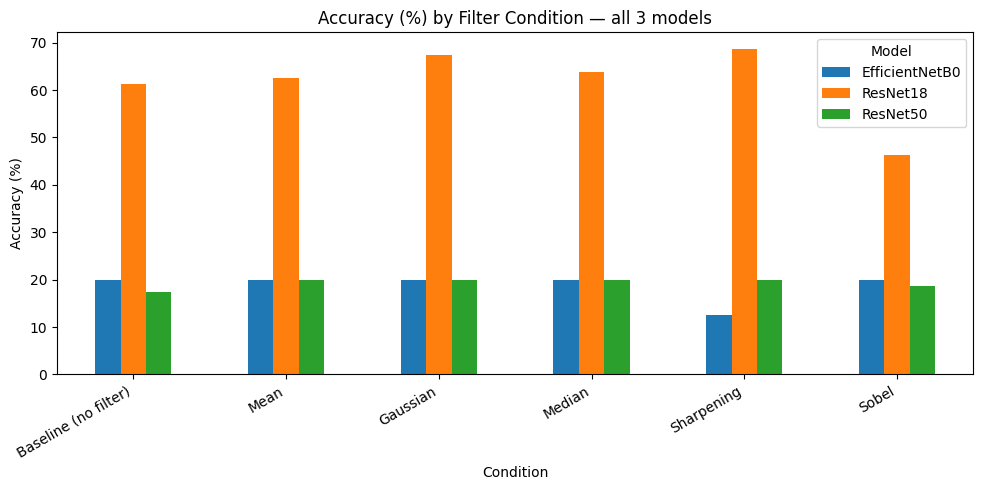

In [24]:

pivot_acc = comparison_df.pivot(index="Condition", columns="Model", values="Accuracy (%)")
pivot_acc = pivot_acc.reindex(list(FILTERS.keys()))
display(pivot_acc)

pivot_acc.plot(kind="bar", figsize=(10, 5))
plt.title("Accuracy (%) by Filter Condition — all 3 models")
plt.ylabel("Accuracy (%)")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig("comparative_accuracy_by_filter.png", dpi=150)
plt.show()

## Section 11 — Discussion Questions

**1. Which three pretrained models performed best in Lab Activity 1?**

EfficientNetB0 (63.75% accuracy), ResNet50 (61.25%), and ResNet18 (58.75%) — these
were the top 3 of the 8 models compared in Lab 1's Table 1.

---

**2. How does filtering affect each of the three models?**

 compare each model's row across the 6 conditions in
`comparison_df`. Note whether accuracy/Macro-F1 goes up, down, or stays flat for each
filter, for each model — they may not respond the same way.]*

---

**3. Which filter produces the greatest change compared with the unfiltered baseline?**
: for each model, subtract the baseline accuracy from each
filtered condition's accuracy — the filter with the largest absolute difference
(positive or negative) is the answer. Report it per model, since it may differ.]*

---

**4. Does the effect of a filter remain consistent across all three models?**
: check the `pivot_acc` table/bar chart from Section 10 — if a
filter, say Sobel, causes a drop for EfficientNetB0 but not for ResNet18, the effect is
**not** consistent, which is itself a valid and expected finding to report.]*

---

**5. Does filtering improve or decrease macro-F1 and balanced accuracy?**

 read the Macro-F1 and Balanced Accuracy columns of
`comparison_df` directly — state clearly, per model and per filter, whether each metric
went up or down relative to baseline.]*

---

**6. Which lesion classes are most affected by filtering?**

compare the per-class precision/recall/F1 tables from Section
9 across conditions — classes whose F1-score swings the most between baseline and a
given filter are the most affected. Melanoma and basal cell carcinoma often rely on
subtle texture/border irregularity, so they are common candidates to check first.]*

---

**7. Why might smoothing remove useful lesion texture or morphological information?**

Smoothing filters (Mean, Gaussian, Median) work by averaging or blending pixel
intensities within a local neighborhood. Skin-lesion diagnosis relies heavily on fine
texture (e.g. pigment network patterns), border irregularity, and small structural
details (e.g. blue-white veils, dots/globules) that are themselves high-frequency
information. Averaging neighboring pixels attenuates exactly this high-frequency
content, so smoothing can blur away the very morphological cues a classifier — or a
dermatologist — would use to distinguish, for example, a benign nevus from an
irregular melanoma. Median filtering preserves edges somewhat better than Mean/Gaussian
(since it doesn't blend across an edge the way an average does), but still discards
fine texture.

---

**8. Why might sharpening or edge detection help or hurt classification?**

Sharpening amplifies high-frequency content (edges, texture boundaries), which **can
help** if the lesion's diagnostic features are genuinely texture/edge-based — it may
make border irregularity or texture patterns more pronounced for the network to pick
up on. However, it **can also hurt**, because sharpening amplifies noise and imaging
artifacts (hair, ruler marks, illumination variation) just as much as genuine lesion
detail, and pretrained ImageNet backbones were never trained on sharpened images, so
the input distribution shifts further from what the backbone's early layers expect.
Sobel edge detection is a more extreme case: it discards all color and intensity
information and keeps only edge magnitude, which throws away color-based diagnostic
cues (e.g. pigmentation patterns) that are often clinically important for skin lesions
— so while it can highlight lesion boundary shape, it typically loses more information
than it gains for this particular task.

---

**9. What is the difference between convolution and correlation?**

Both operations slide a kernel/filter over an image and compute a weighted sum at each
position, but they differ in how the kernel is applied:

- **Correlation** slides the kernel directly over the image and computes the
  element-wise product sum **without flipping** the kernel.
- **Convolution** first **flips the kernel by 180°** (both horizontally and
  vertically) and then slides it over the image, computing the same weighted sum.

For a kernel that is symmetric (e.g. a Gaussian kernel, or the box kernel used in a
Mean filter), flipping it makes no difference, so convolution and correlation produce
identical results — which is why libraries like OpenCV's `cv2.blur`/`GaussianBlur`/
`medianBlur` don't need to distinguish between them. For an asymmetric kernel (e.g. the
Sobel kernel, which is directional), flipping does change the result, so true
convolution and correlation give different outputs. In deep learning, the operation
inside a "convolutional" layer is, strictly speaking, usually implemented as
*cross-correlation* (no kernel flip) rather than mathematical convolution — the
learned kernel weights simply absorb whatever orientation is needed during training,
so the distinction doesn't matter in practice for a CNN's learned filters, only for
fixed, hand-designed filters like Sobel.

---

**10. Based on your results, explain the relationship between classical image
processing and deep-learning-based feature extraction.**

Classical filters (Mean, Gaussian, Median, Sharpening, Sobel) are **fixed,
hand-designed operations** — the same small kernel is applied identically everywhere
in the image, regardless of content, and it extracts one specific, predefined type of
information (blur, edge magnitude, etc.). A CNN's convolutional layers perform the same
basic mathematical operation (a kernel sliding over the image, computing weighted
sums), but the kernel **weights are learned from data** rather than fixed by hand, and
a deep network stacks many such layers, each learning increasingly abstract, task-
specific features (from edges and textures in early layers to lesion-shape or
lesion-type-specific patterns in deeper layers).

This experiment makes that relationship concrete: applying a classical filter before
the CNN amounts to **manually forcing a specific, fixed transformation onto the
input before the network gets to learn its own**. If the classical filter destroys or
distorts information the CNN's own early layers would otherwise have learned to
extract in a task-optimized way (as smoothing does to fine lesion texture), performance
drops. If a classical filter happens to emphasize information that's genuinely useful
and that the pretrained backbone's early layers weren't already extracting well *for
this specific medical-imaging task* (since these backbones were pretrained on natural
ImageNet photos, not skin lesions), it's possible the filter helps by acting as a
form of manual feature engineering. In general, though, the results should show
that letting the CNN learn its own filters from unfiltered data is usually
competitive with or better than hand-designed preprocessing — which is precisely the
motivation for why deep learning replaced classical, hand-engineered pipelines in most
computer-vision tasks over the last decade. *(Once you have your actual numbers, state
explicitly whether your results support or complicate this general expectation.)*


## Section 12 — Export Raw Results (for report)

In [25]:
import json

export = {
    f"{m}__{f}": v for (m, f), v in all_experiment_results.items()
}
with open("task2_all_results.json", "w") as fp:
    json.dump(export, fp, indent=2)

print("Saved task2_all_results.json and task2_comparison_table.csv")
print("Also saved: class_distribution.png, filter_examples.png, per-condition")
print("confusion matrix PNGs, per-condition accuracy/loss curve PNGs, and")
print("comparative_accuracy_by_filter.png — attach these to your report.")

Saved task2_all_results.json and task2_comparison_table.csv
Also saved: class_distribution.png, filter_examples.png, per-condition
confusion matrix PNGs, per-condition accuracy/loss curve PNGs, and
comparative_accuracy_by_filter.png — attach these to your report.
